### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

#1.
df.sort_values(by = 'total_litres_of_pure_alcohol', ascending = False).head(10)

#2. 
media_birra = df['beer_servings'].mean()
media_vino = df['spirit_servings'].mean() 
media_distillati = df['wine_servings'].mean()

#3.
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3

#4.
df.sort_values(by = 'alcohol_index', ascending = False).head(1)['country']

#5.
df_filtered = df[df['beer_servings'] > 100]

#6.
top10 = df.sort_values(by = 'total_litres_of_pure_alcohol', ascending = False).head(10)

#7.
df_sorted = df.sort_values(by = 'country')

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

c:\Users\locor\miniconda3\envs\LabProgrammazione\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analisi per paese:
             Stipendio Medio    Minimo   Massimo  Conteggio
job_country                                                
Albania         79472.500000   43200.0  157500.0          5
Algeria         44550.000000   44100.0   45000.0          2
Argentina      105212.343750   45000.0  222000.0         32
Armenia         78757.000000   45000.0  128682.0          6
Australia      118987.574324   20000.0  257500.0         74
Austria        105269.194444   53014.0  165000.0         18
Azerbaijan      72000.000000   72000.0   72000.0          1
Bahamas        201511.619048  173500.0  284016.0         21
Bangladesh      60981.333333   16500.0   97444.0          3
Belarus        400000.000000  400000.0  400000.0          1


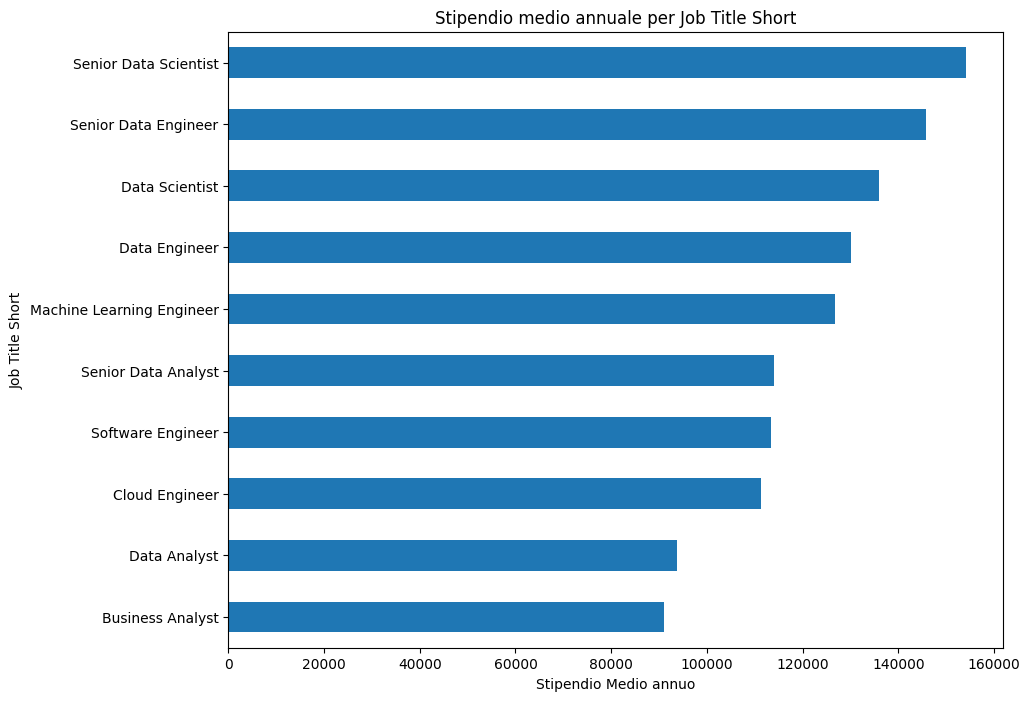

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df_stipendi = df.dropna(subset=['salary_year_avg'])

stipendio_medio = df_stipendi.groupby('job_country')['salary_year_avg'].mean()
stipendio_minimo = df_stipendi.groupby('job_country')['salary_year_avg'].min()
stipendio_massimo = df_stipendi.groupby('job_country')['salary_year_avg'].max()
conteggio_lavori = df_stipendi.groupby('job_country')['salary_year_avg'].count()

analisi_paesi = pd.DataFrame({
    'Stipendio Medio': stipendio_medio,
    'Minimo': stipendio_minimo,
    'Massimo': stipendio_massimo,
    'Conteggio': conteggio_lavori
})

print("Analisi per paese:")
print(analisi_paesi.head(10)) # Mostra i primi 10 paesi

#media per ogni titolo di lavoro
stipendio_per_ruolo = df_stipendi.groupby('job_title_short')['salary_year_avg'].mean()

#ordinamento dati dal piu alto al piu basso
stipendio_per_ruolo_ordinato = stipendio_per_ruolo.sort_values(ascending=True)

#grafico
plt.figure(figsize=(10, 8))
stipendio_per_ruolo_ordinato.plot(kind='barh')

plt.title('Stipendio medio annuale per Job Title Short')
plt.xlabel('Stipendio Medio annuo')
plt.ylabel('Job Title Short')
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

Analisi vendite giornaliere
      Conto Medio  N. Osservazioni  Minimo  Massimo
day                                                
Fri     17.151579               19    5.75    40.17
Sat     20.441379               87    3.07    50.81
Sun     21.410000               76    7.25    48.17
Thur    17.682742               62    7.51    43.11
-----------------------------------
Il giorno con la spesa media più alta è: Sun (21.41€)


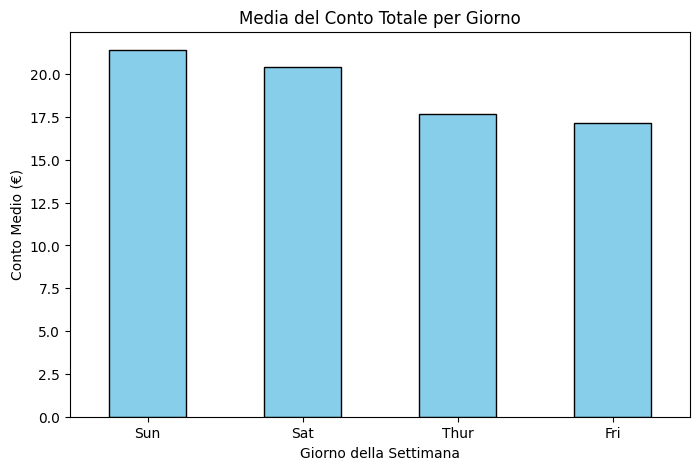

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

#Analisi esplorativa per giorno 
analisi_giorni = df.groupby('day')['total_bill'].agg(['mean', 'count', 'min', 'max'])

analisi_giorni.columns = ['Conto Medio', 'N. Osservazioni', 'Minimo', 'Massimo']

print("Analisi vendite giornaliere")
print(analisi_giorni)
print("-" * 35)

#Creazione della nuova colonna
df['conto_per_persona'] = df['total_bill'] / df['size']

#giorno con il conto medio più alto
giorno_top = analisi_giorni['Conto Medio'].idxmax()
valore_top = analisi_giorni['Conto Medio'].max()

print(f"Il giorno con la spesa media più alta è: {giorno_top} ({valore_top:.2f}€)")

dati_grafico = analisi_giorni['Conto Medio'].sort_values(ascending=False)

#grafico a barre
plt.figure(figsize=(8, 5))
dati_grafico.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Media del Conto Totale per Giorno')
plt.xlabel('Giorno della Settimana')
plt.ylabel('Conto Medio (€)')
plt.xticks(rotation=0)

plt.show()